# Exploration of COLET dataset

The original dataset from this [paper](https://doi.org/10.1016/j.cmpb.2022.106989) has a single *.mat* file containing tabular data from the experiments.

Since this format is not easy to use with *Python*, a MATLAB script was used to extract the relevant data as *.csv* files, which can be easily loaded with *Pandas* library.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

COLET_DATASET_DIR = Path("../datasets/COLET_CSV")
EXP_SELECT = "participant_01/Task_1"

In [2]:
# Load the different daat from eye tracker
gaze_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "gaze.csv")
pupil_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "pupil.csv")
blink_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "blinks.csv")

print(f"Loaded {gaze_df.shape[0]} gaze records:")
display(gaze_df.head(1))
print(f"Loaded {pupil_df.shape[0]} pupil records:")
display(pupil_df.head(5))
print(f"Loaded {blink_df.shape[0]} blink records:")
display(blink_df.head())

Loaded 8205 gaze records:


,gaze_timestamp,confidence,norm_pos_x,norm_pos_y,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z
0,5410.551715,0.999499,0.446264,0.846886,-6.72063,-31.252881,80.700682


Loaded 16406 pupil records:


,pupil_timestamp,eye_id,confidence,norm_pos_x,norm_pos_y,diameter,ellipse_center_x,ellipse_center_y,ellipse_axis_a,ellipse_axis_b
0,5410.553797,1,1.000000,0.406205,0.708513,40.757561,77.991356,55.965595,25.383852,40.757561
1,5410.553797,1,0.999646,0.406235,0.708578,40.764095,77.997212,55.953014,26.110611,40.764095
2,5410.557872,0,0.999661,0.326001,0.395972,38.729047,62.592283,115.973389,23.373748,38.729047
3,5410.557872,0,1.000000,0.325980,0.396084,38.723305,62.588215,115.951805,23.741541,38.723305
4,5410.561675,1,1.000000,0.406046,0.707954,40.842903,77.960808,56.072765,25.485304,40.842903


Loaded 2 blink records:


,id,start_timestamp,duration,end_timestamp,start_frame_index,index,end_frame_index,confidence,filter_response,base_data
0,1,5437.625617,0.236131,5437.861748,37,40,44,0.703872,0.5068225043614704 0.5512669488059149 0.595711...,5437.625617 5437.629564 5437.633621 5437.63786...
1,2,5444.161561,0.180073,5444.341634,231,233,236,0.553669,0.5048782729116744 0.5493227173561188 0.592878...,5444.161561 5444.165642 5444.169793 5444.17554...


In [3]:
# Some insights about the duration of the gaze and pupil data
gaze_start_time = gaze_df['gaze_timestamp'].min()
gaze_end_time = gaze_df['gaze_timestamp'].max()
pupil_start_time = pupil_df['pupil_timestamp'].min()
pupil_end_time = pupil_df['pupil_timestamp'].max()
print(f"Gaze data duration: {gaze_end_time - gaze_start_time} s")
print(f"Pupil data duration: {pupil_end_time - pupil_start_time} s")

print(f"Estimated gaze frequency: {gaze_df.shape[0] / (gaze_end_time - gaze_start_time):.2f} Hz")
print(f"Estimated pupil (right) frequency: {pupil_df[pupil_df.eye_id == 1].shape[0] / (pupil_end_time - pupil_start_time):.2f} Hz")
print(f"Estimated pupil (left) frequency: {pupil_df[pupil_df.eye_id == 0].shape[0] / (pupil_end_time - pupil_start_time):.2f} Hz")


Gaze data duration: 33.80600950000007 s
Pupil data duration: 33.80392700000084 s
Estimated gaze frequency: 242.71 Hz
Estimated pupil (right) frequency: 242.69 Hz
Estimated pupil (left) frequency: 242.63 Hz


It looks like they are using two methods to calculate the pupil related metrics ('2D c++' / '3D c++'). It also seems that there is always one that has a higher confidence, so the diameter will be chosen from the highest confidence value.

Also, it seems like it is always switching between left and right eye for a **combined** frequency of 240Hz

In [4]:
# Sort pupil data by choosing best confidence for each timestamp for each eye
pupil_df_best = pupil_df.groupby(['pupil_timestamp', 'eye_id'], as_index=False).apply(lambda x: x.loc[x['confidence'].idxmax()])
pupil_df_best.reset_index(drop=True, inplace=True)
pupil_df_best.drop(columns=['norm_pos_x', 'norm_pos_y'], inplace=True)
pupil_df_best.rename(columns={'diameter': 'pupil_diameter', 'confidence': 'pupil_confidence'}, inplace=True)
pupil_df_best

,pupil_timestamp,eye_id,pupil_confidence,pupil_diameter,ellipse_center_x,ellipse_center_y,ellipse_axis_a,ellipse_axis_b
0,5410.553797,1,1.000000,40.757561,77.991356,55.965595,25.383852,40.757561
1,5410.557872,0,1.000000,38.723305,62.588215,115.951805,23.741541,38.723305
2,5410.561675,1,1.000000,40.842903,77.960808,56.072765,25.485304,40.842903
3,5410.565491,0,1.000000,39.237560,62.568382,115.802177,23.588182,39.237560
4,5410.571092,1,1.000000,40.950336,77.953743,56.054668,25.205196,40.950336
...,...,...,...,...,...,...,...,...
8198,5444.341634,0,0.735939,30.008591,71.342831,105.565708,22.186894,30.008591
8199,5444.345790,1,0.045619,40.353993,58.252892,55.428499,11.294928,40.353993
8200,5444.350231,0,0.390900,41.681687,66.234522,113.613751,27.634551,41.681687
8201,5444.353666,1,0.657261,42.941853,79.710823,60.829433,27.937931,42.941853


In [309]:
# Merge gaze and pupil data on closest timestamp match
merged_df = pd.merge_asof(gaze_df.sort_values('gaze_timestamp'),
                          pupil_df_best.sort_values('pupil_timestamp'),
                          left_on='gaze_timestamp',
                          right_on='pupil_timestamp',
                          direction='nearest',
                          tolerance=1.0/240*2)  # tolerance in ms
print(f"There are {merged_df[merged_df.pupil_confidence.isna()].index.size} non matching timestamp within the limits")
# Since only one value, drop the row
merged_df_clean = merged_df.dropna()
# Let's reindex the dataframe using timestamp starting from 0 adn dropping the original timestamp columns
merged_df_clean['timestamp'] = merged_df_clean['gaze_timestamp'] - gaze_start_time
merged_df_clean.drop(columns=['gaze_timestamp', 'pupil_timestamp'], inplace=True)

# Rename some columns for clarity
merged_df_clean.rename(columns={
    'pupil_diameter': 'pupil_diameter_mm',
}, inplace=True)

There are 1 non matching timestamp within the limits


Last thing is to downsample to 60 Hz since it will be the max freq. of the Tobii Pro fusion I'm using

In [310]:
# Downsample merged data to 60 Hz
# Convert timestamp to datetime for resampling
merged_df_clean_resampled = merged_df_clean.copy()
merged_df_clean_resampled['timestamp'] = pd.to_timedelta(merged_df_clean_resampled['timestamp'], unit='s')
merged_df_clean_resampled.set_index('timestamp', inplace=True)
merged_df_clean_resampled = merged_df_clean_resampled.resample('16.67ms').mean().interpolate()  # Resample to 60 Hz and interpolate missing values
merged_df_clean_resampled.reset_index(inplace=True)
len(merged_df_clean_resampled)

2028

## Gaze analysis

Let's now visualize the gaze data we are working with

<Axes: title={'center': 'Gaze points in normalized coordinates'}, xlabel='norm_pos_x', ylabel='norm_pos_y'>

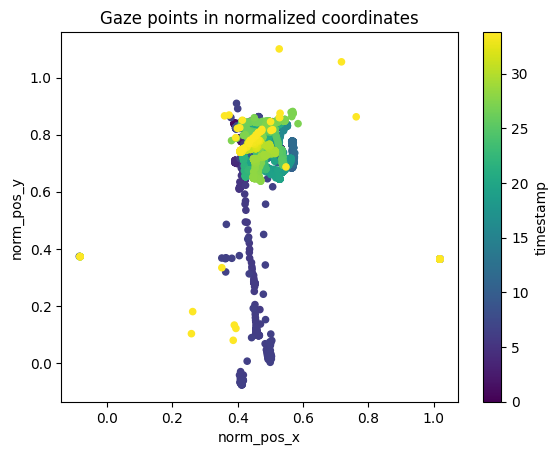

In [6]:
from matplotlib import colormaps

colormap = colormaps.get_cmap("viridis")
merged_df_clean.plot("norm_pos_x", "norm_pos_y", kind='scatter', c='timestamp', colormap=colormap, title="Gaze points in normalized coordinates")

Let's now implement the I-VT algorithm to detect fixations and saccades

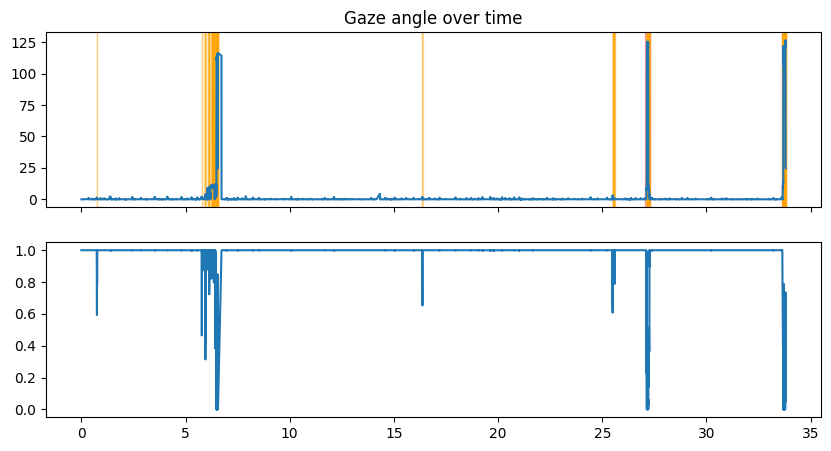

In [11]:
# Create a dataframe with (x,y,z) from current and previous timestamp on the same rows
from matplotlib import pyplot as plt


gaze_angular_data = merged_df_clean[['timestamp', 'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z']].copy()
gaze_angular_data['prev_gaze_point_3d_x'] = gaze_angular_data['gaze_point_3d_x'].shift(1)
gaze_angular_data['prev_gaze_point_3d_y'] = gaze_angular_data['gaze_point_3d_y'].shift(1)
gaze_angular_data['prev_gaze_point_3d_z'] = gaze_angular_data['gaze_point_3d_z'].shift(1)
gaze_angular_data.drop(index=0, inplace=True)  # Drop the first row which has NaN values
gaze_angular_data.head()

def calculate_angle(row):
    if pd.isna(row['prev_gaze_point_3d_x']) or pd.isna(row['prev_gaze_point_3d_y']) or pd.isna(row['prev_gaze_point_3d_z']):
        return np.nan
    v1 = np.array([row['gaze_point_3d_x'], row['gaze_point_3d_y'], row['gaze_point_3d_z']])
    v2 = np.array([row['prev_gaze_point_3d_x'], row['prev_gaze_point_3d_y'], row['prev_gaze_point_3d_z']])
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return np.nan
    cos_theta = dot_product / (norm_v1 * norm_v2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # Clip to avoid numerical issues
    angle_rad = np.arccos(cos_theta)
    angle_deg = np.degrees(angle_rad)
    return angle_deg

gaze_angular_data['gaze_angle'] = gaze_angular_data.apply(calculate_angle, axis=1)
fig, axs = plt.subplots(2,1,figsize=(10, 5), sharex=True)
axs[0].plot(gaze_angular_data['timestamp'], gaze_angular_data['gaze_angle'])
axs[0].title.set_text("Gaze angle over time")

gaze_angular_data[gaze_angular_data.gaze_angle > 20].count()

gaze_angular_data['low_confidence'] = merged_df_clean['pupil_confidence'] < 0.95

# Let's check when are the blinks occurring in the gaze angle data
blink_df_clean = blink_df.copy()
blink_df_clean['timestamp'] = blink_df_clean['start_timestamp'] - gaze_start_time
for _, row in blink_df_clean.iterrows():
    axs[0].axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.3)
# Let's mark zones with low confidence
for _, row in gaze_angular_data[gaze_angular_data.low_confidence].iterrows():
    axs[0].axvspan(row['timestamp'], row['timestamp'] + 1.0/240, color='orange', alpha=0.3)

# Let's also add the confidence level over time on the same plot
y_data = merged_df_clean[['timestamp', 'pupil_confidence']].set_index('timestamp')
axs[1].plot(y_data.index, y_data['pupil_confidence'])



Let's measure the different gaps of low confidence (to eventually label blinks)

In [79]:
low_confidence_df = merged_df_clean[['timestamp', 'pupil_confidence', 'ellipse_axis_a']].copy()
low_confidence_df['low_confidence'] = low_confidence_df['pupil_confidence'] < 0.95
low_confidence_df['transition'] = low_confidence_df['low_confidence'] != low_confidence_df['low_confidence'].shift(1)
low_confidence_df['group'] = low_confidence_df['transition'].cumsum()
low_confidence_df['id'] = low_confidence_df.index
low_confidence_df_gfoup = low_confidence_df.groupby('group').agg({'low_confidence': ['first', 'count'], 'timestamp': ['min', 'max'], 'ellipse_axis_a': ['min', 'max'], 'id': ['min', 'max']})
low_confidence_df_gfoup['duration_ms'] = (low_confidence_df_gfoup['timestamp']['max'] - low_confidence_df_gfoup['timestamp']['min']) * 1000
low_confidence_df_gfoup['openness_delta'] = low_confidence_df_gfoup['ellipse_axis_a']['max'] - low_confidence_df_gfoup['ellipse_axis_a']['min']
low_confidence_df_gfoup[low_confidence_df_gfoup['low_confidence']['first']].head()

print(f"Number of low confidence periods with a single sample: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['low_confidence']['count'] == 1)).sum()}")
print(f"Number of low confidence periods with a duration less than 100 ms: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] < 100)).sum()}")
print(f"Number of possible blink candidates [100-300 ms]: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300)).sum()}")
print(f"Number of long low confidence periods (> 300 ms): {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] > 300)).sum()}")

gaps_to_fill_df = low_confidence_df_gfoup[low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] < 100)]
gaps_to_fill_df = gaps_to_fill_df[[('id', 'min'), ('id', 'max'), ('timestamp', 'min'), ('timestamp', 'max')]].reset_index(drop=True)
gaps_to_fill_df[('id','min')] = gaps_to_fill_df[('id','min')].astype(int)
gaps_to_fill_df[('id','max')] = gaps_to_fill_df[('id','max')].astype(int)

display(gaps_to_fill_df.head())

average_openness_delta_valid_samples = low_confidence_df_gfoup[(~low_confidence_df_gfoup['low_confidence']['first'])]['openness_delta'].mean()
print(f"Average openness delta for valid samples: {average_openness_delta_valid_samples:.2f} mm")
low_confidence_df_gfoup[(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300))]

custom_blinks_df = low_confidence_df_gfoup[(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300))].copy()
custom_blinks_df['start_timestamp'] = custom_blinks_df['timestamp']['min']
custom_blinks_df['stop_timestamp'] = custom_blinks_df['timestamp']['max']
custom_blinks_df['start_id'] = custom_blinks_df['id']['min']
custom_blinks_df['stop_id'] = custom_blinks_df['id']['max']
custom_blinks_df = custom_blinks_df[['start_id', 'stop_id', 'start_timestamp', 'stop_timestamp', 'duration_ms']].reset_index(drop=True)
custom_blinks_df = custom_blinks_df.droplevel(level=1, axis=1)
custom_blinks_df.head()

Number of low confidence periods with a single sample: 22
Number of low confidence periods with a duration less than 100 ms: 36
Number of possible blink candidates [100-300 ms]: 3
Number of long low confidence periods (> 300 ms): 0


id       timestamp          
    min   max       min       max
0   186   186  0.749889  0.749889
1   188   188  0.755894  0.755894
2  1422  1423  5.777089  5.781952
3  1454  1454  5.904703  5.904703
4  1463  1463  5.941953  5.941953

Average openness delta for valid samples: 2.61 mm


,start_id,stop_id,start_timestamp,stop_timestamp,duration_ms
0,1587,1616,6.442226,6.558011,115.7850
1,6551,6581,27.138213,27.260122,121.9085
2,8163,8204,33.644225,33.806010,161.7845


Let's try to interpolate missing values

Also let's truncate the end because the particiapnt was probably moving away from the screen, making the data erronous (not meaningful anyway)

In [12]:
def calculate_gaze_angular_delta(df):
    gaze_angular_data = df[['timestamp', 'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z']].copy()
    gaze_angular_data['prev_gaze_point_3d_x'] = gaze_angular_data['gaze_point_3d_x'].shift(1)
    gaze_angular_data['prev_gaze_point_3d_y'] = gaze_angular_data['gaze_point_3d_y'].shift(1)
    gaze_angular_data['prev_gaze_point_3d_z'] = gaze_angular_data['gaze_point_3d_z'].shift(1)

    gaze_angular_data['gaze_angle_delta_deg'] = gaze_angular_data.apply(calculate_angle, axis=1)
    return gaze_angular_data['gaze_angle_delta_deg']

In [44]:
from scipy.interpolate import interp1d
def interpolate_missing_gaze(eye_data_df, gaps_df, N=100, MIN_MARGINS=10):
    if 'gaze_angle_delta_deg' not in eye_data_df.columns:
        raise ValueError("eye_data_df must contain 'gaze_angle_delta_deg' column")
    if 'pupil_diameter_mm' not in eye_data_df.columns:
        raise ValueError("eye_data_df must contain 'pupil_diameter_mm' column")
    
    if 'id' not in gaps_df.columns:
        raise ValueError("gaps_df must contain 'id' column with 'min' and 'max' keys")
    
    eye_data_df = eye_data_df.copy()
    eye_data_df['interpolated'] = False
    inter_data_df = pd.DataFrame(
        columns=['gap_id', 
                 'original_gaze_angle_delta_deg', 
                 'original_pupil_diameter_mm', 
                 'inter_gaze_angle_delta_deg', 
                 'inter_pupil_diameter_mm'])
    
    for _, gap in gaps_df.iterrows():
        start_id = gap[('id', 'min')].astype(int)
        stop_id = gap[('id', 'max')].astype(int)
        
        if start_id < 0 or stop_id >= len(eye_data_df):
            print(f"Skipping invalid gap with start_id {start_id} and stop_id {stop_id}")
            continue

        # Check if window around the data fits within the dataframe
        window_start = max(0, start_id - N // 2)
        window_end = min(len(eye_data_df) - 1, stop_id + N // 2)
        if window_end - window_start < N:
            print(f"Skipping gap with insufficient data around start_id {start_id} and stop_id {stop_id}")
            continue

        # Discard other low confidence samples (gaps) in the currrent window
        # to avoid using them for interpolation
        gaps_in_window = gaps_df[(gaps_df[('id', 'min')] >= window_start) & (gaps_df[('id', 'max')] <= window_end)]
        if (gaps_in_window[('id', 'max')] - gaps_in_window[('id', 'min')]).sum() > 0.5*N:
            print(f"Skipping gap with too many other gaps in the window around start_id {start_id} and stop_id {stop_id}")
            continue

        # For interpolation, using timestamps outside the gaps
        indices = list(range(window_start, window_end + 1))
        for _, other_gap in gaps_in_window.iterrows():
            other_start_id = other_gap[('id', 'min')].astype(int)
            other_stop_id = other_gap[('id', 'max')].astype(int)
            for i in range(other_start_id, other_stop_id + 1):
                indices.remove(i)
        x = eye_data_df.loc[indices, 'timestamp']
        y_angle = eye_data_df.loc[indices, 'gaze_angle_delta_deg']
        y_pupil = eye_data_df.loc[indices, 'pupil_diameter_mm']
        
        # Create interpolation functions
        interp_angle = interp1d(x, y_angle, kind='linear')
        interp_pupil = interp1d(x, y_pupil, kind='linear')
        
        # Interpolate values for the gap
        gap_timestamps = eye_data_df.loc[start_id:stop_id, 'timestamp']
        interpolated_angles = interp_angle(gap_timestamps)
        interpolated_pupils = interp_pupil(gap_timestamps)
        
        original_angles = eye_data_df.loc[start_id:stop_id, 'gaze_angle_delta_deg'].copy().values
        original_pupils = eye_data_df.loc[start_id:stop_id, 'pupil_diameter_mm'].copy().values
        # Fill in the interpolated values
        eye_data_df.loc[start_id:stop_id, 'gaze_angle_delta_deg'] = interpolated_angles
        eye_data_df.loc[start_id:stop_id, 'pupil_diameter_mm'] = interpolated_pupils
        eye_data_df.loc[start_id:stop_id, 'interpolated'] = True

        # Store interpolation data for analysis
        inter_data_df = pd.concat([inter_data_df, pd.DataFrame({
            'gap_id': start_id,
            'original_gaze_angle_delta_deg': original_angles,
            'original_pupil_diameter_mm': original_pupils,
            'inter_gaze_angle_delta_deg': interpolated_angles,
            'inter_pupil_diameter_mm': interpolated_pupils
        })], ignore_index=True)

    return eye_data_df, inter_data_df

eye_data_df = merged_df_clean.copy()
eye_data_df['gaze_angle_delta_deg'] = calculate_gaze_angular_delta(eye_data_df)
interpolated_eye_data_df, interpolation_analysis_df = interpolate_missing_gaze(eye_data_df, gaps_to_fill_df)
print(f"Interpolated {len(interpolation_analysis_df['gap_id'].unique())} samples across {gaps_to_fill_df.shape[0]} gaps")
interpolation_analysis_df.head()

Interpolated 36 samples across 36 gaps


,gap_id,original_gaze_angle_delta_deg,original_pupil_diameter_mm,inter_gaze_angle_delta_deg,inter_pupil_diameter_mm
0,186,0.402388,42.359602,1.062167,39.957396
1,188,1.016747,41.617882,0.597043,39.340424
2,1422,1.157366,44.454919,0.555084,44.34739
3,1422,2.159587,42.591353,0.533596,44.3456
4,1454,0.015927,42.425387,0.046373,44.967782


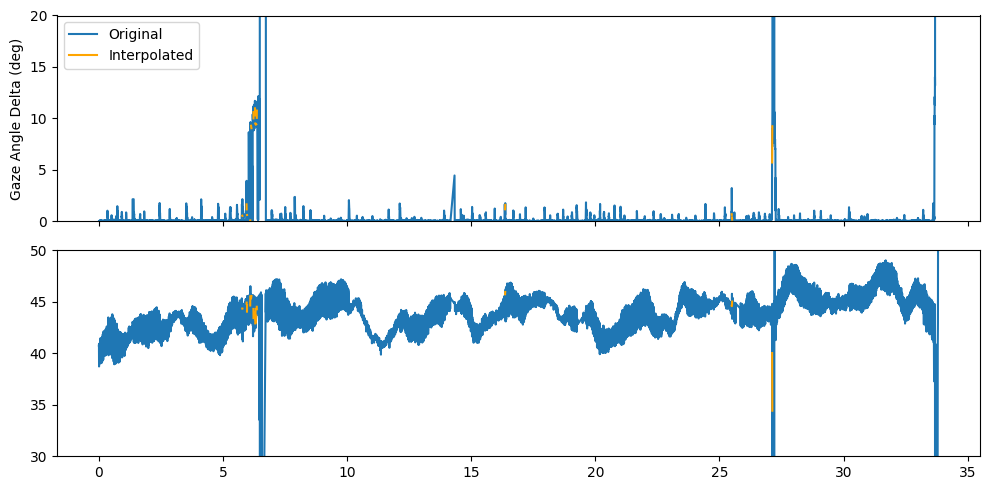

In [95]:
# Lets check out the interpolated data
fig, axs = plt.subplots(2,1,figsize=(10, 5), sharex=True)
axs[0].plot(eye_data_df['timestamp'], eye_data_df['gaze_angle_delta_deg'])
axs[0].set_ylim(0, 20)
interpolated_eye_data_df['transistion'] = interpolated_eye_data_df['interpolated'] != interpolated_eye_data_df['interpolated'].shift(1)
grouped_eye_data = interpolated_eye_data_df.groupby(interpolated_eye_data_df['transistion'].cumsum())
for name, group in grouped_eye_data:
    if group.iloc[0]['interpolated']:
        axs[0].plot(group['timestamp'], group['gaze_angle_delta_deg'], color='orange')
axs[0].set_ylabel('Gaze Angle Delta (deg)')
axs[0].legend(['Original', 'Interpolated'])
axs[1].plot(eye_data_df['timestamp'], eye_data_df['pupil_diameter_mm'])
axs[1].set_ylim(30, 50)
for name, group in grouped_eye_data:
    if group.iloc[0]['interpolated']:
        axs[1].plot(group['timestamp'], group['pupil_diameter_mm'], color='orange')
plt.tight_layout()
plt.show()

Now let's tackle the blinks situation

In [168]:
# First, for the gaze data, just drop the samples in the blinks since interpolating is meaningless
MARGIN = 5
interpolated_gaze_df = interpolated_eye_data_df[
    ['timestamp', 'interpolated', 'gaze_angle_delta_deg', 
     'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z', 
     'norm_pos_x', 'norm_pos_y']
].copy()
for _, row in custom_blinks_df.iterrows():
    # Set gaze points to NaN
    columns = [c for c in interpolated_gaze_df.columns if c not in ['timestamp', 'interpolated']]
    interpolated_gaze_df.loc[(interpolated_gaze_df.index >= row['start_id'] - MARGIN) & (interpolated_gaze_df.index <= row['stop_id'] + MARGIN), columns] = np.nan
interpolated_gaze_df['gaze_angle_delta_deg'].isna().sum()

np.int64(129)

In [169]:
def interpolate_blinks(pupil_df, blink_df, N=200, MIN_SAMPLES=5, MARGIN=5):
    if 'pupil_diameter_mm' not in pupil_df.columns:
        raise ValueError("pupil_df must contain 'pupil_diameter_mm' column")
    
    if not {'start_id', 'stop_id'}.issubset(blink_df.columns):
        raise ValueError("blink_df must contain 'start_id' and 'stop_id' columns")
    
    pupil_df = pupil_df.copy()
    if 'interpolated' not in pupil_df.columns:
        pupil_df['interpolated'] = False
    inter_data_df = pd.DataFrame(
        columns=['blink_id', 
                 'original_pupil_diameter_mm', 
                 'inter_pupil_diameter_mm']
    )
    for idx, blink in blink_df.iterrows():
        start_id = blink['start_id'].astype(int)
        stop_id = blink['stop_id'].astype(int)
        
        if start_id < 0 or stop_id > pupil_df.index.max():
            print(f"Skipping invalid blink with start_id {start_id} and stop_id {stop_id}")
            continue

        # Check if window around the data fits within the dataframe
        window_start = max(0, start_id - N // 2)
        window_end = min(len(pupil_df) - 1, stop_id + N // 2)
        pre_samples_count = (start_id - MARGIN) -window_start
        post_samples_count = window_end - (stop_id + MARGIN)
        if pre_samples_count < MIN_SAMPLES or post_samples_count < MIN_SAMPLES:
            print(f"Skipping blink with insufficient data around start_id {start_id} and stop_id {stop_id}")
            continue

        # For interpolation, using timestamps outside the blinks
        pre_blink_data = pupil_df.loc[window_start:start_id - MARGIN - 1, 'pupil_diameter_mm']
        post_blink_data = pupil_df.loc[stop_id + MARGIN + 1:window_end, 'pupil_diameter_mm']
        x = pd.concat([pre_blink_data, post_blink_data]).index
        y = pd.concat([pre_blink_data, post_blink_data]).values
        interp_func = interp1d(x, y, kind='slinear')
        blink_indices = range(start_id - MARGIN, stop_id + MARGIN + 1)
        interpolated_values = interp_func(blink_indices)
        original_values = pupil_df.loc[blink_indices, 'pupil_diameter_mm'].copy().values
        pupil_df.loc[blink_indices, 'pupil_diameter_mm'] = interpolated_values
        pupil_df.loc[blink_indices, 'interpolated'] = True
        inter_data_df = pd.concat([
            inter_data_df,
            pd.DataFrame({
                'blink_id': idx,
                'original_pupil_diameter_mm': original_values,
                'inter_pupil_diameter_mm': interpolated_values
            })
        ], ignore_index=True)

    return pupil_df, inter_data_df

pupil_df = interpolated_eye_data_df[['timestamp', 'pupil_diameter_mm', 'interpolated']].copy()
inter_pupil_df, inter_pupil_analysis_df = interpolate_blinks(interpolated_eye_data_df, custom_blinks_df)
display(custom_blinks_df.stop_id)
display(gaps_to_fill_df[('id', 'min')][20:])


Skipping blink with insufficient data around start_id 8163 and stop_id 8204


0    1616
1    6581
2    8204
Name: stop_id, dtype: int64

20    1576
21    1579
22    1583
23    1585
24    3962
25    6188
26    6191
27    6195
28    6199
29    6205
30    6207
31    6211
32    6213
33    6547
34    6583
35    6585
Name: (id, min), dtype: int64

Final samples number for interpolated gaze & pupil: 8160


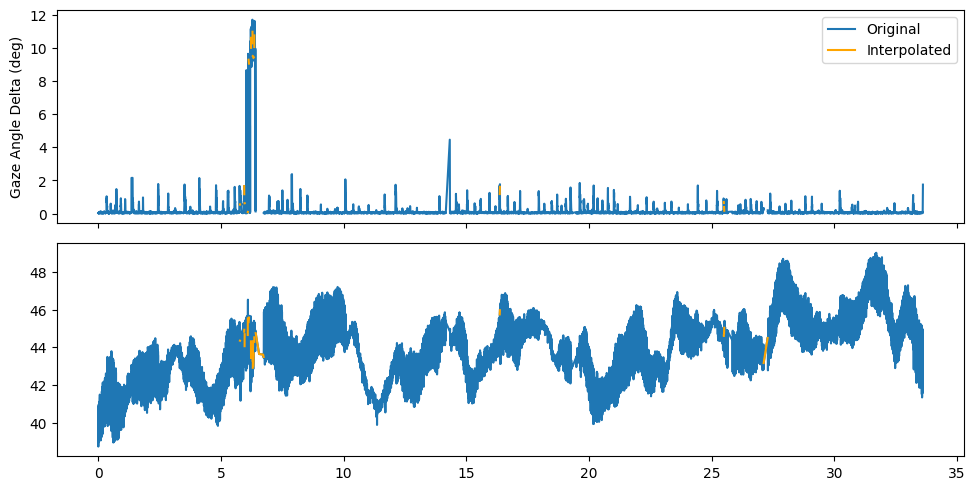

In [175]:
# Lets remove the last samples because meaningless here
inter_merged_eye_df = pd.merge(inter_pupil_df[['timestamp', 'pupil_diameter_mm', 'interpolated']], interpolated_gaze_df, on='timestamp', how='inner', suffixes=('_pupil', '_gaze'))
inter_merged_eye_df = inter_merged_eye_df[:-50]
print(f"Final samples number for interpolated gaze & pupil: {len(inter_merged_eye_df)}")

fig, axs = plt.subplots(2,1,figsize=(10, 5), sharex=True)
axs[0].plot(inter_merged_eye_df['timestamp'], inter_merged_eye_df['gaze_angle_delta_deg'])
inter_merged_eye_df['transistion_gaze'] = inter_merged_eye_df['interpolated_gaze'] != inter_merged_eye_df['interpolated_gaze'].shift(1)
grouped_eye_data = inter_merged_eye_df.groupby(inter_merged_eye_df['transistion_gaze'].cumsum())
for name, group in grouped_eye_data:
    if group.iloc[0]['interpolated_gaze']:
        axs[0].plot(group['timestamp'], group['gaze_angle_delta_deg'], color='orange')
axs[0].set_ylabel('Gaze Angle Delta (deg)')
axs[0].legend(['Original', 'Interpolated'])
axs[1].plot(inter_merged_eye_df['timestamp'], inter_merged_eye_df['pupil_diameter_mm'])
# axs[1].set_ylim(30, 50)
inter_merged_eye_df['transistion_pupil'] = inter_merged_eye_df['interpolated_pupil'] != inter_merged_eye_df['interpolated_pupil'].shift(1)
grouped_pupil_data = inter_merged_eye_df.groupby(inter_merged_eye_df['transistion_pupil'].cumsum())
for name, group in grouped_pupil_data:
    if group.iloc[0]['interpolated_pupil']:
        axs[1].plot(group['timestamp'], group['pupil_diameter_mm'], color='orange')
inter_merged_eye_df.drop(columns=['transistion_gaze', 'transistion_pupil'], inplace=True)
plt.tight_layout()
plt.show()

np.float64(0.004121176337925158)

<Axes: xlabel='timestamp'>

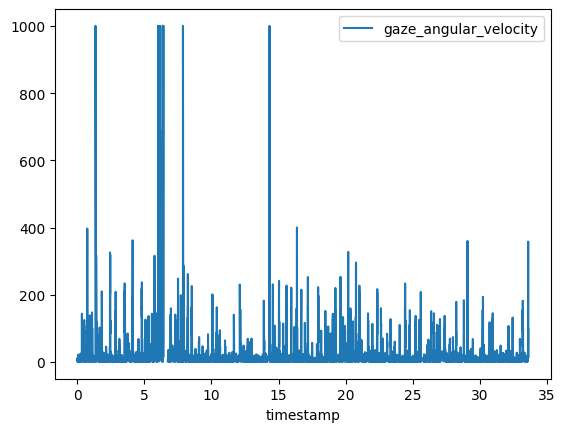

In [193]:
def calculate_angular_velocity(gaze_df, absolute=True, LIMITS=(-1000, 1000)):
    if 'gaze_angle_delta_deg' not in gaze_df.columns:
        raise ValueError("gaze_df must contain 'gaze_angle_delta_deg' column")

    gaze_angular_data = gaze_df[['timestamp', 'gaze_angle_delta_deg']].copy()
    gaze_angular_data['prev_gaze_angle_delta_deg'] = gaze_angular_data['gaze_angle_delta_deg'].shift(1)
    gaze_angular_data['delta_time'] = (gaze_angular_data['timestamp'] - gaze_angular_data['timestamp'].shift(1))
    display(gaze_angular_data['delta_time'].mean())

    def angular_velocity(row):
        if pd.isna(row['prev_gaze_angle_delta_deg']) or pd.isna(row['gaze_angle_delta_deg']):
            return np.nan
        delta_angle = row['gaze_angle_delta_deg'] - row['prev_gaze_angle_delta_deg']
        delta_time = row['delta_time']
        if delta_time == 0:
            return np.nan
        angular_velocity = delta_angle / delta_time
        angular_velocity = np.clip(angular_velocity, LIMITS[0], LIMITS[1])
        return abs(angular_velocity) if absolute else angular_velocity
    
    gaze_angular_data['gaze_angular_velocity'] = gaze_angular_data.apply(angular_velocity, axis=1)
    return gaze_angular_data['gaze_angular_velocity']

interpolated_gaze_df['gaze_angular_velocity'] = calculate_angular_velocity(interpolated_gaze_df, absolute=True)
interpolated_gaze_df.plot('timestamp', 'gaze_angular_velocity')

Found 205 transitions between saccades and fixations
Will mark 154 short fixations as saccades


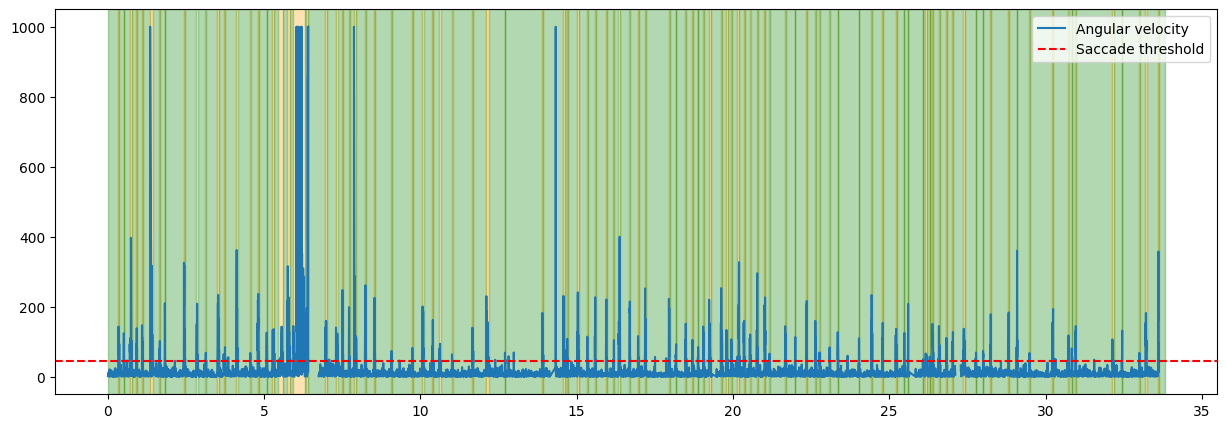

In [246]:
VELOCITY_THRESH = 45

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(interpolated_gaze_df['timestamp'], interpolated_gaze_df['gaze_angular_velocity'], label='Angular velocity')
ax.axhline(VELOCITY_THRESH, color='red', linestyle='--', label='Saccade threshold')
ax.legend()

# Let's mark the zones for saccades and fixations based on the angular velocity
interpolated_gaze_df['saccade'] = interpolated_gaze_df['gaze_angular_velocity'] > VELOCITY_THRESH
interpolated_gaze_df['fixation'] = ~interpolated_gaze_df['saccade']
print(f"Found {interpolated_gaze_df['transition'].sum()} transitions between saccades and fixations")

# 1- Fixations should have a minimum duration of 55 ms (COLET dataset) ~15 datapoins
interpolated_gaze_df['transition'] = interpolated_gaze_df['saccade'] != interpolated_gaze_df['saccade'].shift(1)
interpolated_gaze_df['id'] = interpolated_gaze_df.index
grouped_transitions = interpolated_gaze_df.groupby(interpolated_gaze_df['transition'].cumsum())
# find groups of fixations with a duration less than 55 ms and mark them as saccades
fixation_groups = grouped_transitions.agg({'fixation': ['first', 'count'], 'id': ['min', 'max']})
print(f"Will mark {((fixation_groups[('fixation', 'count')] < 15) & (fixation_groups[('fixation', 'first')])).sum()} short fixations as saccades")
for idx, group in fixation_groups.iterrows():
    if group['fixation']['count'] < 15 and group['fixation']['first']:  # 55 ms at 250 Hz sampling rate
        # Mark the entire group as saccade
        interpolated_gaze_df.loc[group['id']['min']:group['id']['max'], 'saccade'] = True
        interpolated_gaze_df.loc[group['id']['min']:group['id']['max'], 'fixation'] = False


# Merge if only one sample in the transition to avoid marking very short saccades or fixations
interpolated_gaze_df['saccade'] = interpolated_gaze_df['saccade'].astype(np.int32)
interpolated_gaze_df['fixation'] = interpolated_gaze_df['fixation'].astype(np.int32)
interpolated_gaze_df['transition'] = interpolated_gaze_df['saccade'] != interpolated_gaze_df['saccade'].shift(1)
grouped_transitions = interpolated_gaze_df.groupby(interpolated_gaze_df['transition'].cumsum())
single_samples = grouped_transitions.agg({'saccade': 'count', 'id': 'first', 'fixation': 'count'})
single_samples = single_samples[(single_samples['saccade'] == 1) | (single_samples['fixation'] == 1)]['id']
interpolated_gaze_df.loc[single_samples, 'saccade'] = pd.NA
interpolated_gaze_df.loc[single_samples, 'fixation'] = pd.NA
# Interpolate nearest neighbor to fill the single sample gaps
interpolated_gaze_df['saccade'] = interpolated_gaze_df['saccade'].interpolate(method='nearest')
interpolated_gaze_df['fixation'] = interpolated_gaze_df['fixation'].interpolate(method='nearest')
interpolated_gaze_df['saccade'] = interpolated_gaze_df['saccade'].astype(np.bool)
interpolated_gaze_df['fixation'] = interpolated_gaze_df['fixation'].astype(np.bool)

interpolated_gaze_df['transition'] = interpolated_gaze_df['saccade'] != interpolated_gaze_df['saccade'].shift(1)
grouped_transitions = interpolated_gaze_df.groupby(interpolated_gaze_df['transition'].cumsum())
for idx, group in grouped_transitions:
    if group.iloc[0]['saccade']:
        ax.axvspan(group.iloc[0]['timestamp'], group.iloc[-1]['timestamp'], color='orange', alpha=0.3)
    else:
        ax.axvspan(group.iloc[0]['timestamp'], group.iloc[-1]['timestamp'], color='green', alpha=0.3)

Text(0.5, 1.0, 'Fixation Centroids and Radius')

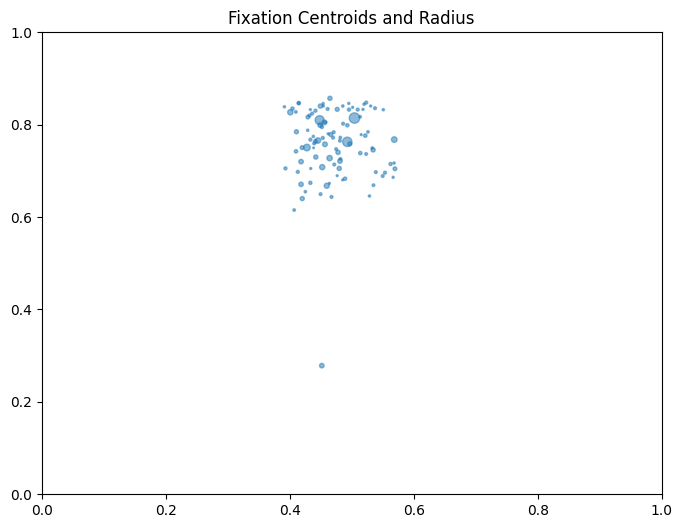

In [258]:
# Lets create a df for the fixations infos
fixation_durations = []
fixation_positions = []
fixation_radius = []
fixation_timestamps = []

grouped_transitions = interpolated_gaze_df.groupby(interpolated_gaze_df['transition'].cumsum())
for idx, group in grouped_transitions:
    if not group.iloc[0]['saccade']:
        fixation_durations.append(group.shape[0] / 250)  # Convert to seconds (assuming 250 Hz sampling rate)
        mean_x, mean_y = group['norm_pos_x'].mean(), group['norm_pos_y'].mean()
        fixation_positions.append((mean_x, mean_y))
        fixation_radius.append(((group['norm_pos_x']-mean_x)**2 + (group['norm_pos_y']-mean_y)**2).max()**0.5)  # Approximate radius as distance from mean position
        fixation_timestamps.append(group.iloc[0]['timestamp'])

fixation_df = pd.DataFrame({
    'duration': fixation_durations,
    'x': [pos[0] for pos in fixation_positions],
    'y': [pos[1] for pos in fixation_positions],
    'radius': fixation_radius,
    'timestamp': fixation_timestamps
})
len(fixation_df)

# Plot the fixation centroid positions and radius using scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(fixation_df['x'], fixation_df['y'], s=fixation_df['radius']*1000, alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Fixation Centroids and Radius')

In [259]:
# Create the saccade df
saccade_durations = []
saccade_timestamps = []

grouped_transitions = interpolated_gaze_df.groupby(interpolated_gaze_df['transition'].cumsum())
for idx, group in grouped_transitions:
    if group.iloc[0]['saccade']:
        saccade_durations.append(group.shape[0] / 250)  # Convert to seconds (assuming 250 Hz sampling rate)
        saccade_timestamps.append(group.iloc[0]['timestamp'])

saccade_df = pd.DataFrame({
    'duration': saccade_durations,
    'timestamp': saccade_timestamps
})

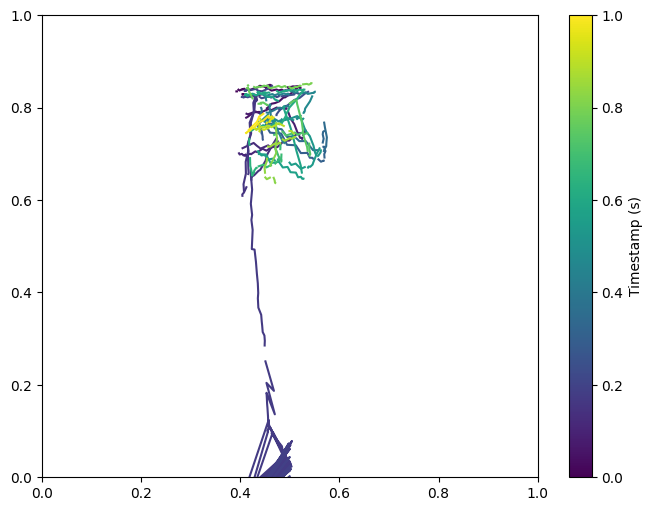

In [278]:
# Plots saccades trails on the normalized screen coordinates
fig, ax = plt.subplots(figsize=(8, 6))
colormap = colormaps.get_cmap("viridis")
for idx, group in interpolated_gaze_df.groupby(interpolated_gaze_df['transition'].cumsum()):
    if group.iloc[0]['saccade']:
        c = colormap(group.iloc[0]['timestamp'] / interpolated_eye_data_df['timestamp'].max())  # Normalize saccade value (assuming max saccade value is 100)
        ax.plot(group['norm_pos_x'], group['norm_pos_y'], color=c)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.colorbar(plt.cm.ScalarMappable(cmap=colormap), label='Timestamp (s)', ax=ax)

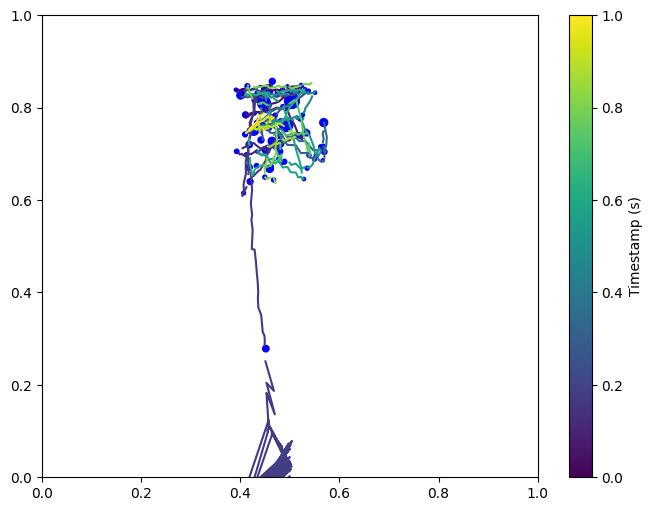

In [287]:
# Combined plot of fixations and saccades
fig, ax = plt.subplots(figsize=(8, 6))
colormap = colormaps.get_cmap("viridis")
for idx, group in interpolated_gaze_df.groupby(interpolated_gaze_df['transition'].cumsum()):
    if group.iloc[0]['saccade']:
        c = colormap(group.iloc[0]['timestamp'] / interpolated_eye_data_df['timestamp'].max())  # Normalize saccade value (assuming max saccade value is 100)
        ax.plot(group['norm_pos_x'], group['norm_pos_y'], color=c)
ax.scatter(fixation_df['x'], fixation_df['y'], s=fixation_df['radius']*2000, color='blue', label='Fixations')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.colorbar(plt.cm.ScalarMappable(cmap=colormap), label='Timestamp (s)', ax=ax)

Now its time to look at the pupil diameter change frequency.

Should use the IPA (Index of Pupillary Acticity) or a discrete wavelet transform for more details (coefficients)